Importing plotly failed. Interactive plots will not work.
14:47:49 - cmdstanpy - INFO - Chain [1] start processing
14:47:49 - cmdstanpy - INFO - Chain [1] done processing
14:47:49 - cmdstanpy - INFO - Chain [1] start processing
14:47:49 - cmdstanpy - INFO - Chain [1] done processing
14:47:49 - cmdstanpy - INFO - Chain [1] start processing
14:47:49 - cmdstanpy - INFO - Chain [1] done processing
14:47:49 - cmdstanpy - INFO - Chain [1] start processing
14:47:49 - cmdstanpy - INFO - Chain [1] done processing
14:47:49 - cmdstanpy - INFO - Chain [1] start processing
14:47:49 - cmdstanpy - INFO - Chain [1] done processing
14:47:49 - cmdstanpy - INFO - Chain [1] start processing
14:47:49 - cmdstanpy - INFO - Chain [1] done processing
14:47:49 - cmdstanpy - INFO - Chain [1] start processing
14:47:49 - cmdstanpy - INFO - Chain [1] done processing
14:47:49 - cmdstanpy - INFO - Chain [1] start processing
14:47:50 - cmdstanpy - INFO - Chain [1] done processing
/opt/homebrew/Cellar/jupyterlab/4.4.6/


=== En İyi Parametreler ===
Prophet: {'changepoint_prior_scale': 0.05, 'seasonality_mode': 'multiplicative'}
Holt-Winters: {'trend': 'mul', 'seasonal': 'add', 'm': 12}
SARIMA: {'order': (1, 1, 0), 'seasonal_order': (0, 1, 2, 12)}

=== Performans Karşılaştırması (2025-01..07) ===
             Model   MAE  RMSE    MAPE   sMAPE
     Prophet (opt) 70.42 84.26 54.35 % 39.83 %
Holt-Winters (opt) 66.94 78.22 54.30 % 39.26 %
      SARIMA (opt) 51.35 78.03 45.02 % 30.10 %

=== Tahmin Tablosu (2025-01..07) ===
   Tarih        Gerçek    Prophet_Tahmin  HW_Tahmin   SARIMA_Tahmin
 2025-01-01      160           150           160           129     
 2025-02-01       96           129           168            89     
 2025-03-01      218           199           200           155     
 2025-04-01      219           137           155           161     
 2025-05-01      112           206           226           126     
 2025-06-01      244           364           338           242     
 2025-07-01      

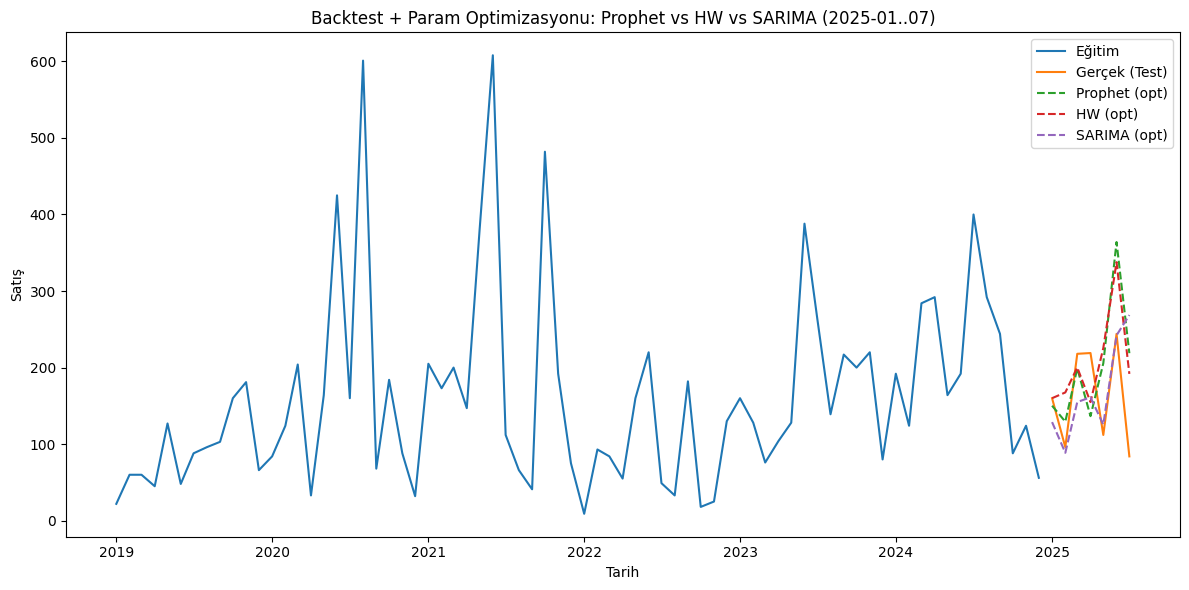

In [1]:
# ============================================
#  Sales Forecast – 3 Model + Param Optimizasyon
#  Train: 2019-01 .. 2024-12 (MS)
#  Test : 2025-01 .. 2025-07  (MS)
#  Modeller: Prophet, Holt-Winters, SARIMA
#  Metrikler: MAE, RMSE, MAPE, sMAPE
#  Stok No: '303-104092' 
# ============================================

import warnings
warnings.filterwarnings("ignore")

from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet  # pip install prophet

# ---------- 0) Yardımcı fonksiyonlar ----------
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom = np.where(denom == 0, 1.0, denom)  # 0'a bölmeyi engelle
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def evaluate(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true==0, 1, y_true))) * 100
    sm   = smape(y_true, y_pred)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "sMAPE": sm}

# ---------- 1) Veri ----------
data = {
"2019-01":22,"2019-02":60,"2019-03":60,"2019-04":45,"2019-05":127,
"2019-06":48,"2019-07":88,"2019-08":96,"2019-09":103,"2019-10":160,
"2019-11":181,"2019-12":66,"2020-01":84,"2020-02":124,"2020-03":204,
"2020-04":33,"2020-05":164,"2020-06":425,"2020-07":160,"2020-08":601,
"2020-09":68,"2020-10":184,"2020-11":88,"2020-12":32,"2021-01":205,
"2021-02":173,"2021-03":200,"2021-04":147,"2021-05":380,"2021-06":608,
"2021-07":112,"2021-08":66,"2021-09":41,"2021-10":482,"2021-11":192,
"2021-12":75,"2022-01":9,"2022-02":93,"2022-03":84,"2022-04":55,
"2022-05":160,"2022-06":220,"2022-07":49,"2022-08":33,"2022-09":182,
"2022-10":18,"2022-11":25,"2022-12":130,"2023-01":160,"2023-02":128,
"2023-03":76,"2023-04":104,"2023-05":128,"2023-06":388,"2023-07":264,
"2023-08":139,"2023-09":217,"2023-10":200,"2023-11":220,"2023-12":80,
"2024-01":192,"2024-02":124,"2024-03":284,"2024-04":292,"2024-05":164,
"2024-06":192,"2024-07":400,"2024-08":292,"2024-09":244,"2024-10":88,
"2024-11":124,"2024-12":56,"2025-01":160,"2025-02":96,"2025-03":218,
"2025-04":219,"2025-05":112,"2025-06":244,"2025-07":84
}

# Aylık seri (MS = Month Start) uyumlu index
s = pd.Series(data)
s.index = pd.to_datetime(s.index)                 # ayın 1'i
idx_all = pd.date_range("2019-01-01", "2025-07-01", freq="MS")
s = s.reindex(idx_all).astype(float)

train = s.loc["2019-01-01":"2024-12-01"]         # 2019-01..2024-12
test  = s.loc["2025-01-01":"2025-07-01"]         # 2025-01..2025-07
steps = len(test)
y_true = test.to_numpy()

# ---------- 2) Prophet – Grid Search ----------
# Küçük ama etkili bir ızgara; gerekirse genişletin
prophet_grid = {
    "changepoint_prior_scale": [0.01, 0.05, 0.1, 0.5],
    "seasonality_mode": ["additive", "multiplicative"],
    # "seasonality_prior_scale": [1.0, 5.0, 10.0],   # isterseniz açın
}

best_prophet_params = None
best_prophet_pred = None
best_prophet_mae = np.inf

df_train = pd.DataFrame({"ds": train.index, "y": train.values})
for cps, smode in product(prophet_grid["changepoint_prior_scale"], prophet_grid["seasonality_mode"]):
    try:
        m = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            changepoint_prior_scale=cps,
            seasonality_mode=smode
        )
        m.fit(df_train)
        future = m.make_future_dataframe(periods=steps, freq="MS")
        fcst = m.predict(future)
        mask = (fcst["ds"] >= pd.Timestamp("2025-01-01")) & (fcst["ds"] <= pd.Timestamp("2025-07-01"))
        y_pred = fcst.loc[mask, "yhat"].to_numpy()

        if len(y_pred) == steps:
            mae = mean_absolute_error(y_true, y_pred)
            if mae < best_prophet_mae:
                best_prophet_mae = mae
                best_prophet_params = {"changepoint_prior_scale": cps, "seasonality_mode": smode}
                best_prophet_pred = y_pred
    except Exception:
        continue

# ---------- 3) Holt-Winters – Grid Search ----------
# Additive vs Multiplicative kombinasyonları
hw_grid = {
    "trend": ["add", "mul"],
    "seasonal": ["add", "mul"],
    "seasonal_periods": [12]  # gerekirse [6, 12] deneyebilirsiniz
}

best_hw_params = None
best_hw_pred = None
best_hw_mae = np.inf

for trend, seasonal, m in product(hw_grid["trend"], hw_grid["seasonal"], hw_grid["seasonal_periods"]):
    try:
        hw_model = ExponentialSmoothing(train, trend=trend, seasonal=seasonal, seasonal_periods=m)
        hw_fit = hw_model.fit(optimized=True)
        y_pred = hw_fit.forecast(steps).to_numpy()
        mae = mean_absolute_error(y_true, y_pred)
        if mae < best_hw_mae:
            best_hw_mae = mae
            best_hw_params = {"trend": trend, "seasonal": seasonal, "m": m}
            best_hw_pred = y_pred
    except Exception:
        continue

# ---------- 4) SARIMA – Grid Search ----------
# Küçük AIC/validasyon araması (MAE'ye göre seçiyoruz)
pdq_grid  = [(p,1,q) for p in [0,1,2] for q in [0,1,2]]
PDQ_grid  = [(P,1,Q,12) for P in [0,1] for Q in [0,1,2]]

best_sarima_params = None
best_sarima_pred = None
best_sarima_mae = np.inf

for order in pdq_grid:
    for sorder in PDQ_grid:
        try:
            model = SARIMAX(train, order=order, seasonal_order=sorder,
                            enforce_stationarity=False, enforce_invertibility=False)
            res = model.fit(disp=False)
            y_pred = res.get_forecast(steps=steps).predicted_mean.to_numpy()
            mae = mean_absolute_error(y_true, y_pred)
            if mae < best_sarima_mae:
                best_sarima_mae = mae
                best_sarima_params = {"order": order, "seasonal_order": sorder}
                best_sarima_pred = y_pred
        except Exception:
            continue

# ---------- 5) Metrikler ve Karşılaştırma ----------
metrics = []
metrics.append(evaluate(y_true, best_prophet_pred, "Prophet (opt)"))
metrics.append(evaluate(y_true, best_hw_pred,       "Holt-Winters (opt)"))
metrics.append(evaluate(y_true, best_sarima_pred,   "SARIMA (opt)"))

metrics_df = pd.DataFrame(metrics)
print("\n=== En İyi Parametreler ===")
print("Prophet:", best_prophet_params)
print("Holt-Winters:", best_hw_params)
print("SARIMA:", best_sarima_params)

print("\n=== Performans Karşılaştırması (2025-01..07) ===")
print(metrics_df.to_string(index=False, formatters={
    "MAE":   lambda x: f"{x:,.2f}",
    "RMSE":  lambda x: f"{x:,.2f}",
    "MAPE":  lambda x: f"{x:,.2f} %",
    "sMAPE": lambda x: f"{x:,.2f} %"
}))

compare_df = pd.DataFrame({
    "Tarih": test.index,
    "Gerçek": y_true,
    "Prophet_Tahmin": best_prophet_pred,
    "HW_Tahmin": best_hw_pred,
    "SARIMA_Tahmin": best_sarima_pred
})
print("\n=== Tahmin Tablosu (2025-01..07) ===")
print(compare_df.to_string(index=False, justify="center", col_space=12, formatters={
    "Gerçek":           lambda x: f"{x:.0f}",
    "Prophet_Tahmin":   lambda x: f"{x:.0f}",
    "HW_Tahmin":        lambda x: f"{x:.0f}",
    "SARIMA_Tahmin":    lambda x: f"{x:.0f}"
}))

# ---------- 6) Grafik ----------
PLOT = True
if PLOT:
    plt.figure(figsize=(12,6))
    plt.plot(train.index, train.values, label="Eğitim")
    plt.plot(test.index,  test.values,  label="Gerçek (Test)")
    plt.plot(test.index,  best_prophet_pred, "--", label="Prophet (opt)")
    plt.plot(test.index,  best_hw_pred,      "--", label="HW (opt)")
    plt.plot(test.index,  best_sarima_pred,  "--", label="SARIMA (opt)")
    plt.title("Backtest + Param Optimizasyonu: Prophet vs HW vs SARIMA (2025-01..07)")
    plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(); plt.tight_layout()
    plt.show()
